#ML4Net - Lab 1

## Team members

Antoine Metz 335801 | Corentin Le Bris 335776

## Description

In this lab, you are going to get introduced into Multi-Armed Bandits (MABs) and Wi-Fi simulations. More specifically, you are going to implement a MAB algorithm that performs channel allocation in an Overlapping Basic Service Set (OBSS), i.e., in a scenario where multiple independent BSSs coexist.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 8 May 2026 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Download the Simulator's source code

In [ ]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip

--2026-05-03 13:34:28--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip [following]
--2026-05-03 13:34:29--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 979661 (957K) [application/zip]
Saving to: ‘Komondor-lightweight.zip.1’

Komondor-lightweigh 100%[===================>] 956.70K  --.-KB/s    in 0.05s 

3. Define the main path of the code

In [ ]:
mypath="drive/MyDrive/AAX/Lab1"

4. Extract the source code

In [ ]:
!mkdir -p "$mypath"
!cp -f Komondor-lightweight.zip "$mypath"
!cd "$mypath" && unzip -o Komondor-lightweight.zip

Archive:  Komondor-lightweight.zip
  inflating: config_models           
  inflating: learning_modules/ml_model.h  
  inflating: main/traffic_generator.h  
  inflating: methods/auxiliary_methods.h  
  inflating: input/agents_monitoring.csv  
  inflating: input/input_nodes.csv   
  inflating: structures/action.h     
  inflating: main/compcxx_komondor_main.h  
  inflating: main/komondor_main.cc   
  inflating: main/build_local        
  inflating: structures/controller_report.h  
  inflating: structures/performance.h  
  inflating: methods/modulations_methods.h  
  inflating: structures/logger.h     
  inflating: structures/node_configuration.h  
  inflating: learning_modules/pre_processor.h  
  inflating: structures/logical_nack.h  
  inflating: list_of_macros.h        
  inflating: structures/notification.h  
  inflating: main/agent.h            
  inflating: structures/FIFO.h       
  inflating: methods/agent_methods.h  
  inflating: structures/modulations.h  
  inflating: main/centr

5. Give permissions to run the code

In [ ]:
!sudo apt-get install -y lib32stdc++6

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
lib32stdc++6 is already the newest version (12.3.0-1ubuntu1~22.04.3).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!cd $mypath/; chmod -R 777 *

6. Compile the code

In [ ]:
!cd $mypath/main; ./build_local

## How to run simulations

Komondor can be run by calling its compiled main file ("komondor_main") and indicating the value for different flags.

Next, you will see two different ways of running Komondor, depending on whether MAB Agents are instantiated or not.

In any case, **it is important to know** that:


*   Any input files used by the simulator will be located in the `/input` folder.
*   Any output files generated by the simulator will be located in the `/output` folder.

Apart from that, Komondor generates a set of console logs that give meaningful information.


### 1) Simulations without agents

To simulate specific scenarios (described using "input node" files) **without agents**, one must indicate the following flags:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (NO AGENTS)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [ ]:
# RUN THE SIMULATION

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS DISABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 0
  - script_output_filename: ../output/logs_test.txt
  - simulation_code: AAX-LAB1
  - save_node_logs: 1
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINISTICALLY through NODES input file...
  - Reading nodes input file '../input/

### 2) Simulations with agents (used for keeping track of temporary performance)

To simulate specific scenarios (described using "input node" files) **with agents**, one must indicate the following flags:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_monitoring.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_test_agents.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=0

# Flag to indicate whether "AGENT LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_AGENT_LOGS=0

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Flag to indicate whether "AGENT LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_AGENT_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

Run the simulation

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring.csv
  - script_output_filename: ../output/logs_test_agents.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMI

## EXERCISES

### Exercise 1:
Run the simulator (without agents) for the provided input nodes file (`/input/input_nodes.csv`). Before running the simulation, activate the flag that allows saving node logs into a file. After running the simulation, use the information from the log files of each node (e.g., AP_A, STA_A1, AP_B, STA_B1) to plot the scenario. To make the plot, consider the position of the nodes, the channel used, and the power strength that each node perceives from each other node in the deployment.

*Note: To know the power strength perceived by a given device (e.g., AP A) from any other devices (e.g., STA A1, AP B, STA B1), check the logs of that node and identify the cases where other nodes are detected to start/stop a transmission.*

In [ ]:
# (response to exercise 1)

In [ ]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

# We reuse mypath defined earlier in the notebook.
# Exercise 1 requires running the simulator without agents,
# while saving node logs.

INPUT_FILE_NODES = "../input/input_nodes.csv"
OUTPUT_FILE_LOGS = "../output/logs_exercise1.txt"
SIMULATION_CODE = "AAX-LAB1-EX1"

FLAG_SAVE_NODE_LOGS = 1
FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 0

SIM_TIME = 100
SEED = 7

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS DISABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 0
  - script_output_filename: ../output/logs_exercise1.txt
  - simulation_code: AAX-LAB1-EX1
  - save_node_logs: 1
  - print_system_logs: 1
  - print_node_logs: 0
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX1.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINISTICALLY through NODES input file...
  - Reading nodes input fi

In [ ]:
#We read the input file
if mypath.startswith("/"):
    base_path = mypath
else:
    base_path = os.path.join("/content", mypath)

input_nodes_path = os.path.join(base_path, "input", "input_nodes.csv")
output_path = os.path.join(base_path, "output")

nodes = pd.read_csv(input_nodes_path, sep=None, engine="python")
nodes.columns = [col.strip() for col in nodes.columns]

print("Detected columns:")
print(nodes.columns.tolist())

display(nodes)

Detected columns:
['node_code', 'node_type', 'wlan_code', 'x(m)', 'y(m)', 'z(m)', 'central_freq (GHz)', 'channel_bonding_model', 'primary_channel', 'min_channel_allowed', 'max_channel_allowed', 'tx_power', 'sensitivity', 'traffic_model', 'traffic_load(pkts/s)', 'packet_length', 'num_packets_aggregated', 'capture_effect_model', 'capture_effect_thr', 'constant PER', 'pifs_activated', 'backoff_type', 'cw_adaptation', 'cw_min', 'cw_max', 'cw_stage']


,node_code,node_type,wlan_code,x(m),y(m),z(m),central_freq (GHz),channel_bonding_model,primary_channel,min_channel_allowed,...,num_packets_aggregated,capture_effect_model,capture_effect_thr,constant PER,pifs_activated,backoff_type,cw_adaptation,cw_min,cw_max,cw_stage
0,AP_A,0,A,0,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
1,STA_A1,1,A,0,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
2,AP_B,0,B,5,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
3,STA_B1,1,B,5,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5


In [ ]:
#We prepare data
def find_column(possible_names):
    normalized_columns = {
        col: col.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col in nodes.columns
    }

    for name in possible_names:
        normalized_name = name.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col, normalized_col in normalized_columns.items():
            if normalized_name in normalized_col:
                return col

    return None


col_x = find_column(["x"])
col_y = find_column(["y"])
col_channel = find_column(["primary channel", "primary_channel", "channel", "ch"])
col_node = find_column(["node_code", "node code", "node", "name", "id"])
col_type = find_column(["node_type", "node type", "type"])
col_wlan = find_column(["wlan_code", "wlan code", "wlan", "bss"])

print("x column:", col_x)
print("y column:", col_y)
print("channel column:", col_channel)
print("node column:", col_node)
print("type column:", col_type)
print("WLAN/BSS column:", col_wlan)

nodes = nodes.copy()

if col_node is not None:
    nodes["node_name"] = nodes[col_node].astype(str).str.strip()
elif col_type is not None and col_wlan is not None:
    nodes["node_name"] = (
        nodes[col_type].astype(str).str.strip()
        + "_"
        + nodes[col_wlan].astype(str).str.strip()
    )
else:
    nodes["node_name"] = ["Node_" + str(i) for i in range(len(nodes))]

nodes[col_x] = pd.to_numeric(nodes[col_x], errors="coerce")
nodes[col_y] = pd.to_numeric(nodes[col_y], errors="coerce")

if col_channel is not None:
    nodes["channel_used"] = nodes[col_channel].astype(str).str.strip()
else:
    nodes["channel_used"] = "unknown"

display(nodes[["node_name", col_x, col_y, "channel_used"]])

x column: x(m)
y column: node_type
channel column: primary_channel
node column: node_code
type column: node_type
WLAN/BSS column: wlan_code


,node_name,x(m),node_type,channel_used
0,AP_A,0,0,0
1,STA_A1,0,1,0
2,AP_B,5,0,0
3,STA_B1,5,1,0


In [ ]:
#Check log files

log_files = glob.glob(os.path.join(output_path, "*.txt"))

print("All output text files:")
for file in log_files:
    print(os.path.basename(file))

All output text files:
logs_test.txt
logs_test_agents.txt
logs_exercise1.txt
logs_output__N1_STA_A1.txt
logs_output__N3_STA_B1.txt
logs_output__N0_AP_A.txt
logs_output__N2_AP_B.txt


In [ ]:
# ============================
# Exercise 1 - Extract perceived powers
# ============================

# Komondor logs use internal node IDs: N0, N1, N2, N3...
# According to the log filenames:
# N0 -> AP_A
# N1 -> STA_A1
# N2 -> AP_B
# N3 -> STA_B1

node_names = nodes["node_name"].tolist()

# Build a mapping between Komondor node IDs and readable node names
# We assume that the row order in input_nodes.csv corresponds to N0, N1, N2, ...
node_id_to_name = {
    f"N{i}": node_names[i]
    for i in range(len(node_names))
}

print("Node ID mapping:")
for node_id, node_name in node_id_to_name.items():
    print(node_id, "->", node_name)

# Keep only node log files, such as logs_output__N0_AP_A.txt
candidate_logs = []

for file in log_files:
    filename = os.path.basename(file)

    if "logs_output__N" in filename:
        candidate_logs.append(file)

print("\nNode log files used:")
for file in candidate_logs:
    print(os.path.basename(file))

# Patterns used to parse the logs
receiver_pattern = re.compile(r"logs_output__(N\d+)_")
tx_pattern = re.compile(r"InportSomeNodeStartTX\(\):\s+(N\d+)\s+to\s+(N\d+)")
power_line_pattern = re.compile(r"Power sensed per channel \[dBm\]:(.*)")
number_pattern = re.compile(r"-?\d+(?:\.\d+)?|-inf")

power_records = []

for log_file in candidate_logs:

    filename = os.path.basename(log_file)

    receiver_match = receiver_pattern.search(filename)

    if receiver_match is None:
        continue

    receiver_id = receiver_match.group(1)
    receiver_name = node_id_to_name.get(receiver_id, receiver_id)

    print("\nReading:", filename, "as receiver:", receiver_name)

    pending_transmitter_id = None
    lines_read = 0
    max_lines_to_read = 200000

    with open(log_file, "r", errors="ignore") as file:

        for line in file:
            lines_read += 1

            if lines_read > max_lines_to_read:
                print("Stopped early after", max_lines_to_read, "lines.")
                break

            # Detect the node that starts a transmission
            tx_match = tx_pattern.search(line)

            if tx_match is not None:
                pending_transmitter_id = tx_match.group(1)
                continue

            # Ignore the "BEFORE updating" line
            if "BEFORE updating" in line:
                continue

            # Detect the line containing the sensed power
            power_match = power_line_pattern.search(line)

            if power_match is None:
                continue

            if pending_transmitter_id is None:
                continue

            # Ignore self-transmissions
            if pending_transmitter_id == receiver_id:
                continue

            values_text = power_match.group(1)
            values = number_pattern.findall(values_text)

            finite_values = []

            for value in values:
                if value != "-inf":
                    finite_values.append(float(value))

            if len(finite_values) == 0:
                continue

            # In this scenario, the useful received power is the finite sensed value
            perceived_power = max(finite_values)

            transmitter_name = node_id_to_name.get(
                pending_transmitter_id,
                pending_transmitter_id
            )

            power_records.append({
                "receiver": receiver_name,
                "transmitter": transmitter_name,
                "power_dbm": perceived_power,
                "receiver_id": receiver_id,
                "transmitter_id": pending_transmitter_id,
                "log_line": line.strip()
            })

powers = pd.DataFrame(power_records)

if len(powers) == 0:
    print("\nNo perceived power values were extracted.")
    powers_summary = pd.DataFrame(columns=["receiver", "transmitter", "power_dbm"])
else:
    print("\nExtracted perceived power values:")
    display(powers.head(20))

    # Several values can be detected for the same pair.
    # We use the median to summarize the perceived power between two nodes.
    powers_summary = (
        powers
        .groupby(["receiver", "transmitter"], as_index=False)["power_dbm"]
        .median()
    )

    print("\nSummary of perceived powers:")
    display(powers_summary)

Node ID mapping:
N0 -> AP_A
N1 -> STA_A1
N2 -> AP_B
N3 -> STA_B1

Node log files used:
logs_output__N1_STA_A1.txt
logs_output__N3_STA_B1.txt
logs_output__N0_AP_A.txt
logs_output__N2_AP_B.txt

Reading: logs_output__N1_STA_A1.txt as receiver: STA_A1
Stopped early after 200000 lines.

Reading: logs_output__N3_STA_B1.txt as receiver: STA_B1
Stopped early after 200000 lines.

Reading: logs_output__N0_AP_A.txt as receiver: AP_A
Stopped early after 200000 lines.

Reading: logs_output__N2_AP_B.txt as receiver: AP_B
Stopped early after 200000 lines.

Extracted perceived power values:


,receiver,transmitter,power_dbm,receiver_id,transmitter_id,log_line
0,STA_A1,AP_B,-87.466035,N1,N2,0.000061000891000;N1;S0;E18; · Power sensed...
1,STA_A1,STA_B1,-77.108599,N1,N3,0.000129000000000;N1;S0;E18; · Power sensed...
2,STA_A1,AP_B,-87.466035,N1,N2,0.000189000000000;N1;S12;E18; · Power sense...
3,STA_A1,STA_B1,-77.108599,N1,N3,0.005665000000000;N1;S12;E18; · Power sense...
4,STA_A1,AP_A,-69.646758,N1,N0,0.005749000632000;N1;S0;E18; · Power sensed...
5,STA_A1,AP_A,-69.646758,N1,N0,0.005876999998000;N1;S11;E18; · Power sense...
6,STA_A1,AP_B,-87.466035,N1,N2,0.011437000602000;N1;S0;E18; · Power sensed...
7,STA_A1,STA_B1,-77.108599,N1,N3,0.011504999996000;N1;S0;E18; · Power sensed...
8,STA_A1,AP_B,-87.466035,N1,N2,0.011564999996000;N1;S12;E18; · Power sense...
9,STA_A1,STA_B1,-77.108599,N1,N3,0.017040999996000;N1;S12;E18; · Power sense...



Summary of perceived powers:


,receiver,transmitter,power_dbm
0,AP_A,AP_B,-77.108599
1,AP_A,STA_A1,-69.646758
2,AP_A,STA_B1,-87.466035
3,AP_B,AP_A,-77.108599
4,AP_B,STA_A1,-87.466035
5,AP_B,STA_B1,-69.646758
6,STA_A1,AP_A,-69.646758
7,STA_A1,AP_B,-87.466035
8,STA_A1,STA_B1,-77.108599
9,STA_B1,AP_A,-87.466035


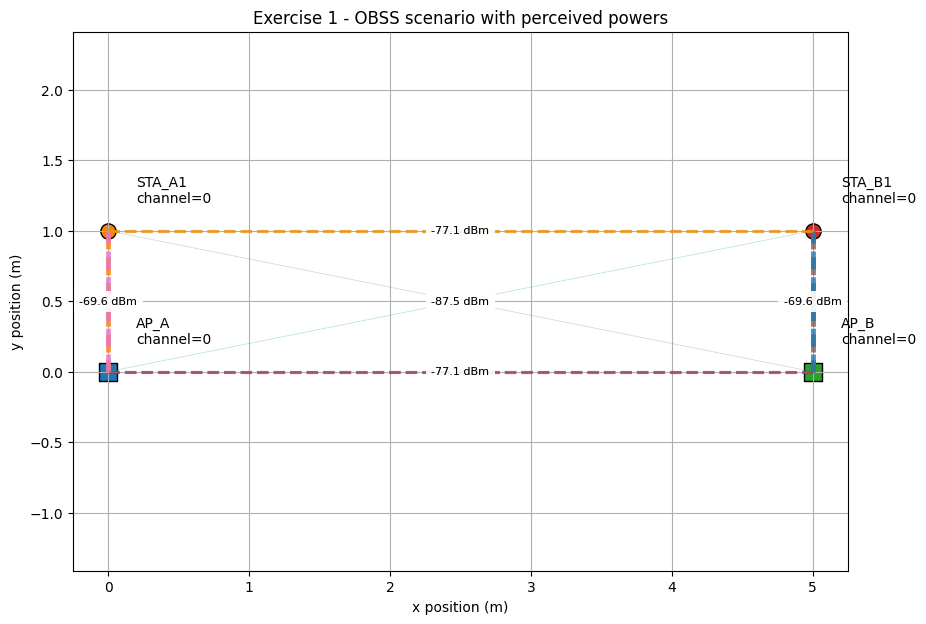

In [ ]:
# ============================
# Exercise 1 - Plot scenario
# ============================

plt.figure(figsize=(10, 7))

# Draw perceived-power links when they were successfully extracted.
if len(powers_summary) > 0:

    min_power = powers_summary["power_dbm"].min()
    max_power = powers_summary["power_dbm"].max()

    for _, row in powers_summary.iterrows():

        receiver = row["receiver"]
        transmitter = row["transmitter"]
        power = row["power_dbm"]

        tx_row = nodes[nodes["node_name"] == transmitter].iloc[0]
        rx_row = nodes[nodes["node_name"] == receiver].iloc[0]

        x_tx, y_tx = tx_row[col_x], tx_row[col_y]
        x_rx, y_rx = rx_row[col_x], rx_row[col_y]

        # Normalize the received power to adapt the link thickness.
        # A value closer to 0 dBm corresponds to a stronger signal.
        if max_power != min_power:
            normalized_power = (power - min_power) / (max_power - min_power)
        else:
            normalized_power = 0.5

        line_width = 0.5 + 3 * normalized_power
        alpha = 0.25 + 0.55 * normalized_power

        plt.plot(
            [x_tx, x_rx],
            [y_tx, y_rx],
            linestyle="--",
            linewidth=line_width,
            alpha=alpha
        )

        plt.text(
            (x_tx + x_rx) / 2,
            (y_tx + y_rx) / 2,
            f"{power:.1f} dBm",
            fontsize=8,
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

# Draw nodes.
for _, row in nodes.iterrows():

    node_name = row["node_name"]
    x = row[col_x]
    y = row[col_y]
    channel = row["channel_used"]

    if "AP" in str(node_name).upper():
        marker = "s"
        size = 180
    else:
        marker = "o"
        size = 120

    plt.scatter(
        x,
        y,
        s=size,
        marker=marker,
        edgecolor="black"
    )

    plt.text(
        x + 0.2,
        y + 0.2,
        f"{node_name}\nchannel={channel}",
        fontsize=10
    )

plt.title("Exercise 1 - OBSS scenario with perceived powers")
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.grid(True)
plt.axis("equal")
plt.show()

### Exercise 1 analysis

In this first exercise, the goal was to visualize the initial Wi-Fi scenario before introducing any learning agent. The simulator was executed without agents, using the provided `input_nodes.csv` file. The node log saving flag was enabled in order to extract the received power perceived by each device.

The plot represents the physical deployment of the OBSS scenario. Each point corresponds to one device: access points are represented with square markers, while stations are represented with circular markers. The labels also indicate the channel used by each node. In this scenario, all devices use channel 0, which means that they can potentially interfere with each other.

The dashed lines represent the received power perceived between devices. These values were extracted from the node log files generated by Komondor. In the logs, each node is identified internally as `N0`, `N1`, `N2`, and `N3`, which correspond respectively to `AP_A`, `STA_A1`, `AP_B`, and `STA_B1`.

The received powers are expressed in dBm. They are negative because the received Wi-Fi signal is usually much lower than 1 mW. A value closer to 0 dBm means a stronger signal, while a more negative value means a weaker signal. For example, `-69.6 dBm` is stronger than `-77.1 dBm`, and `-87.5 dBm` is the weakest signal observed in this scenario.

The results are coherent with the position of the nodes. Devices that are close to each other, such as `AP_A` and `STA_A1` or `AP_B` and `STA_B1`, perceive each other with a stronger signal of about `-69.6 dBm`. Devices that are farther away perceive each other with weaker signals, such as `-77.1 dBm` or `-87.5 dBm`.

Therefore, this plot summarizes the spatial deployment, the channel allocation, and the perceived signal strength between the different nodes in the OBSS scenario.

### Exercise 2:

Run the simulator (this time, with agents in "monitor" mode) for the provided input nodes file (`/input/input_nodes.csv`). The input agents file to be used is provided as (`/input/agents_monitoring.csv`). Ensure that the agent logs are saved into files by setting the corresponding flag to 1. After running the simulation, use the agent log files to plot the temporary throughput obtained by each AP.

In [ ]:
# In this exercise, the simulator is run with agents in monitoring mode.
# These agents do not optimize the channel yet. They only record the temporary throughput.

INPUT_FILE_NODES = "../input/input_nodes.csv"
INPUT_FILE_AGENTS = "../input/agents_monitoring.csv"

OUTPUT_FILE_LOGS = "../output/logs_exercise2_agents.txt"
SIMULATION_CODE = "AAX-LAB1-EX2-AGENTS"

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1

FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 0
FLAG_PRINT_AGENT_LOGS = 0

SIM_TIME = 100
SEED = 7

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring.csv
  - script_output_filename: ../output/logs_exercise2_agents.txt
  - simulation_code: AAX-LAB1-EX2-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 0
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX2-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating 

In [ ]:
# Exercise 2 - Find agent log files


if mypath.startswith("/"):
    base_path = mypath
else:
    base_path = os.path.join("/content", mypath)

output_path = os.path.join(base_path, "output")

all_output_files = glob.glob(os.path.join(output_path, "*.txt"))

print("All output text files:")
for file in all_output_files:
    print(os.path.basename(file))

# We keep the files generated for agents.
# Depending on the simulator version, their names usually contain "agent".
agent_log_files = []

for file in all_output_files:
    filename = os.path.basename(file).lower()

    if "agent" in filename:
        agent_log_files.append(file)

print("\nPossible agent log files:")
for file in agent_log_files:
    print(os.path.basename(file))

All output text files:
logs_test.txt
logs_test_agents.txt
logs_exercise1.txt
logs_output__N1_STA_A1.txt
logs_output__N3_STA_B1.txt
logs_output__N0_AP_A.txt
logs_output__N2_AP_B.txt
logs_exercise2_agents.txt
logs_output_AAX-LAB1-EX2-AGENTS_A0_A.txt
logs_output_AAX-LAB1-EX2-AGENTS_A1_B.txt

Possible agent log files:
logs_test_agents.txt
logs_exercise2_agents.txt
logs_output_AAX-LAB1-EX2-AGENTS_A0_A.txt
logs_output_AAX-LAB1-EX2-AGENTS_A1_B.txt


In [ ]:
# Exercise 2 - Inspect agent logs

for log_file in agent_log_files:
    print("\n==============================")
    print(os.path.basename(log_file))
    print("==============================")

    with open(log_file, "r", errors="ignore") as file:
        for i, line in enumerate(file):
            print(line.strip())

            if i >= 50:
                break


logs_test_agents.txt
KOMONDOR SIMULATION 'AAX-LAB1-AGENTS' (seed 7);{21.21,21.14};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{5.64,5.64};{5.11,5.15};{7.50,7.52};
KOMONDOR SIMULATION 'AAX-LAB1-AGENTS' (seed 7);{21.21,21.14};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{5.64,5.64};{5.11,5.15};{7.50,7.52};
KOMONDOR SIMULATION 'AAX-LAB1-AGENTS' (seed 7);{21.21,21.14};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{5.64,5.64};{5.11,5.15};{7.50,7.52};
KOMONDOR SIMULATION 'AAX-LAB1-AGENTS' (seed 7);{21.21,21.14};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{5.64,5.64};{5.11,5.15};{7.50,7.52};

logs_exercise2_agents.txt
KOMONDOR SIMULATION 'AAX-LAB1-EX2-AGENTS' (seed 7);{0.00,0.00};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{-1000.00,-1000.00};{0.00,0.00};{69727.00,69758.00};

logs_output_AAX-LAB1-EX2-AGENTS_A0_A.txt
0.000000000000000000;A0;B00; Start()
0.000000000000000;A0;F00; ComputeN

In [ ]:
# Exercise 2 - Extract temporary throughput

throughput_records = []

# Komondor usually identifies agents/APs with N0, N2, etc.
# In this scenario, AP_A is N0 and AP_B is N2.
node_id_to_ap = {
    "N0": "AP_A",
    "N2": "AP_B"
}

# Patterns
node_pattern = re.compile(r"(N\d+)")
number_pattern = re.compile(r"-?\d+(?:\.\d+)?")

for log_file in agent_log_files:

    filename = os.path.basename(log_file)

    # Try to detect the AP from the filename first
    ap_name = None
    for node_id, name in node_id_to_ap.items():
        if node_id.lower() in filename.lower() or name.lower() in filename.lower():
            ap_name = name
            break

    if ap_name is None:
        ap_name = filename.replace(".txt", "")

    print("Reading:", filename, "as", ap_name)

    with open(log_file, "r", errors="ignore") as file:
        for line in file:

            line_clean = line.strip()
            line_lower = line_clean.lower()

            # We only keep lines related to throughput
            if "throughput" not in line_lower:
                continue

            numbers = number_pattern.findall(line_clean)

            # We need at least a time value and a throughput value
            if len(numbers) < 2:
                continue

            # First number is usually time, last number is usually throughput
            time_value = float(numbers[0])
            throughput_value = float(numbers[-1])

            # If the line contains an AP/node ID, use it
            node_match = node_pattern.search(line_clean)
            if node_match is not None:
                detected_node = node_match.group(1)
                ap_name_line = node_id_to_ap.get(detected_node, ap_name)
            else:
                ap_name_line = ap_name

            throughput_records.append({
                "ap": ap_name_line,
                "time": time_value,
                "throughput": throughput_value,
                "log_line": line_clean
            })

throughput_df = pd.DataFrame(throughput_records)

if len(throughput_df) == 0:
    print("No throughput values were extracted automatically.")
    print("Check the previous cell to see the exact format of the agent logs.")
else:
    print("Extracted temporary throughput values:")
    display(throughput_df.head(20))

    print("\nNumber of extracted values per AP:")
    display(throughput_df.groupby("ap").size().reset_index(name="count"))

Reading: logs_test_agents.txt as logs_test_agents
Reading: logs_exercise2_agents.txt as logs_exercise2_agents
Reading: logs_output_AAX-LAB1-EX2-AGENTS_A0_A.txt as logs_output_AAX-LAB1-EX2-AGENTS_A0_A
Reading: logs_output_AAX-LAB1-EX2-AGENTS_A1_B.txt as logs_output_AAX-LAB1-EX2-AGENTS_A1_B
Extracted temporary throughput values:


,ap,time,throughput,log_line
0,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,0.5,21.43,0.500000000000000;A0;C03; · Average through...
1,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,1.0,21.43,1.000000000000000;A0;C03; · Average through...
2,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,1.5,19.61,1.500000000000000;A0;C03; · Average through...
3,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,2.0,22.80,2.000000000000000;A0;C03; · Average through...
4,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,2.5,20.52,2.500000000000000;A0;C03; · Average through...
5,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,3.0,21.89,3.000000000000000;A0;C03; · Average through...
6,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,3.5,21.43,3.500000000000000;A0;C03; · Average through...
7,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,4.0,20.06,4.000000000000000;A0;C03; · Average through...
8,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,4.5,18.24,4.500000000000000;A0;C03; · Average through...
9,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,5.0,20.06,5.000000000000000;A0;C03; · Average through...



Number of extracted values per AP:


,ap,count
0,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,199
1,logs_output_AAX-LAB1-EX2-AGENTS_A1_B,199


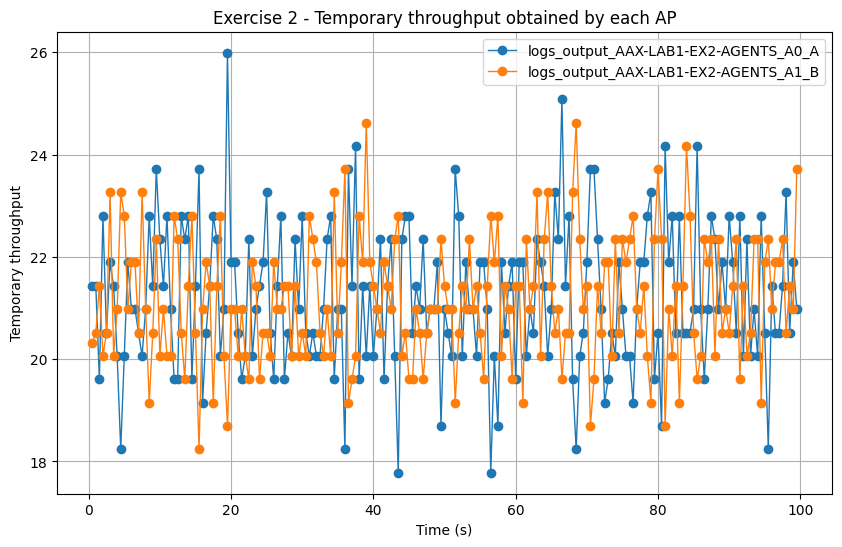

In [ ]:
# Exercise 2 - Plot temporary throughput


if len(throughput_df) > 0:

    plt.figure(figsize=(10, 6))

    for ap_name in throughput_df["ap"].unique():

        ap_data = throughput_df[throughput_df["ap"] == ap_name]

        plt.plot(
            ap_data["time"],
            ap_data["throughput"],
            marker="o",
            linewidth=1,
            label=ap_name
        )

    plt.title("Exercise 2 - Temporary throughput obtained by each AP")
    plt.xlabel("Time (s)")
    plt.ylabel("Temporary throughput")
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print("No throughput data available to plot.")

### Exercise 2 analysis

In this exercise, the simulator was executed with agents in monitoring mode. The same `input_nodes.csv` file was used as in Exercise 1, but the simulator was also provided with the `agents_monitoring.csv` file. The agent log saving flag was enabled so that each agent generated a log file during the simulation.

In monitoring mode, the agents do not perform any learning and do not modify the channel allocation. This is confirmed by the console output: both agents have `learning_mechanism: 0` and `action_selection_strategy: 0`. Therefore, their role is only to periodically request performance information from their associated AP.

The generated agent logs show that each agent requests information every 0.5 seconds. For each request, the log displays the current action, the channel used, the CCA threshold, the transmission power, the maximum bandwidth, and the measured performance. In this scenario, both agents always use `Action (0)`, corresponding to channel 0. This is expected because the monitoring file only defines one channel action.

The temporary throughput values were extracted from the lines containing `Average throughput`. For example, agent `A0`, associated with WLAN A, records throughput values around 20–23 Mbps at the beginning of the simulation. Agent `A1`, associated with WLAN B, records similar values. This is consistent with the final simulation report, where AP_A obtains about 21.21 Mbps and AP_B obtains about 21.14 Mbps.

This exercise provides a baseline for the next parts of the lab. Since the agents only monitor the network, the throughput observed here corresponds to the fixed channel allocation scenario. In the following exercises, learning agents will be allowed to choose between different channel actions, and their performance can be compared against this monitoring baseline.

### Exercise 3:

Copy the `agents_monitoring.csv` file, rename it as `agents_egreedy.csv`, and modify it as follows:
- Indicate the possible "channel actions" by indicating `0,1` in the column 'actions channels' of each agent.
- Set the colum "learning mechanism" to `1`(which stands for multi-armed bandits) for each agent.
- Set the column "selected strategy" to `1` (which stands for ɛ-greedy) for each agent.

Then, run the simulation using `agents_egreedy.csv` and plot the temporary throughput obtained by each AP, as done in Exercise 2. In addition, read the console logs from Komondor and explain the displayed agent logs.

**Important:** In case of experiencing a run-time error, check that the fields in the 'agents' file are separated by a semicolon (`;`).

In [ ]:
# Exercise 3 - Create epsilon-greedy agents file

# Paths
input_path = os.path.join(base_path, "input")

agents_monitoring_path = os.path.join(input_path, "agents_monitoring.csv")
agents_egreedy_path = os.path.join(input_path, "agents_egreedy.csv")

# Read the monitoring agents file.
# The lab statement says that the fields must be separated by semicolons.
agents_df = pd.read_csv(agents_monitoring_path, sep=";")
agents_df.columns = [col.strip() for col in agents_df.columns]

print("Columns in agents_monitoring.csv:")
print(agents_df.columns.tolist())

display(agents_df)

Columns in agents_monitoring.csv:
['Wlan code', 'centralized', 'time between requests (seconds)', 'actions channels', 'actions cca (dBm)', 'actions tx power (dBm)', 'max_bw', 'reward', 'learning mechanism', 'selected_strategy']


,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,0,-82,15,1,2,0,0
1,B,0,0.5,0,-82,15,1,2,0,0


In [ ]:
# Exercise 3 - Modify agent parameters


def find_agent_column(possible_names):
    normalized_columns = {
        col: col.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col in agents_df.columns
    }

    for name in possible_names:
        normalized_name = name.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col, normalized_col in normalized_columns.items():
            if normalized_name in normalized_col:
                return col

    return None


col_actions_channels = find_agent_column([
    "actions channels",
    "action channels",
    "actions_channels",
    "action_channels"
])

col_learning_mechanism = find_agent_column([
    "learning mechanism",
    "learning_mechanism",
    "learning mechanism type"
])

col_selected_strategy = find_agent_column([
    "selected strategy",
    "selected_strategy",
    "strategy"
])

print("Column used for channel actions:", col_actions_channels)
print("Column used for learning mechanism:", col_learning_mechanism)
print("Column used for selected strategy:", col_selected_strategy)

# Apply the required modifications for epsilon-greedy MAB.
agents_egreedy = agents_df.copy()

agents_egreedy[col_actions_channels] = "0,1"
agents_egreedy[col_learning_mechanism] = 1
agents_egreedy[col_selected_strategy] = 1

display(agents_egreedy)

# Save the new agents file using semicolons.
agents_egreedy.to_csv(agents_egreedy_path, sep=";", index=False)

print("agents_egreedy.csv created at:")
print(agents_egreedy_path)

Column used for channel actions: actions channels
Column used for learning mechanism: learning mechanism
Column used for selected strategy: selected_strategy


,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,1
1,B,0,0.5,"0,1",-82,15,1,2,1,1


agents_egreedy.csv created at:
/content/drive/MyDrive/AAX/Lab1/input/agents_egreedy.csv


In [ ]:
# Exercise 3 - Run epsilon-greedy simulation


INPUT_FILE_NODES = "../input/input_nodes.csv"
INPUT_FILE_AGENTS = "../input/agents_egreedy.csv"

OUTPUT_FILE_LOGS = "../output/logs_exercise3_egreedy.txt"
SIMULATION_CODE = "AAX-LAB1-EX3-EGREEDY"

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1

FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 0

# We print agent logs because the exercise asks us to explain the displayed agent logs.
FLAG_PRINT_AGENT_LOGS = 1

SIM_TIME = 100
SEED = 7

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_egreedy.csv
  - script_output_filename: ../output/logs_exercise3_egreedy.txt
  - simulation_code: AAX-LAB1-EX3-EGREEDY
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 0
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX3-EGREEDY.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating 

In [ ]:
#Find generated logs


all_output_files = glob.glob(os.path.join(output_path, "*.txt"))

print("All output text files:")
for file in all_output_files:
    print(os.path.basename(file))

# Keep files related to Exercise 3 or agent logs.
exercise3_logs = []

for file in all_output_files:
    filename = os.path.basename(file).lower()

    if "exercise3" in filename or "egreedy" in filename or "agent" in filename:
        exercise3_logs.append(file)

print("\nPossible Exercise 3 / agent log files:")
for file in exercise3_logs:
    print(os.path.basename(file))

All output text files:
logs_test.txt
logs_test_agents.txt
logs_exercise1.txt
logs_output__N1_STA_A1.txt
logs_output__N3_STA_B1.txt
logs_output__N0_AP_A.txt
logs_output__N2_AP_B.txt
logs_exercise2_agents.txt
logs_output_AAX-LAB1-EX2-AGENTS_A0_A.txt
logs_output_AAX-LAB1-EX2-AGENTS_A1_B.txt
logs_exercise3_egreedy.txt
logs_output_AAX-LAB1-EX3-EGREEDY_A0_A.txt
logs_output_AAX-LAB1-EX3-EGREEDY_A1_B.txt

Possible Exercise 3 / agent log files:
logs_test_agents.txt
logs_exercise2_agents.txt
logs_output_AAX-LAB1-EX2-AGENTS_A0_A.txt
logs_output_AAX-LAB1-EX2-AGENTS_A1_B.txt
logs_exercise3_egreedy.txt
logs_output_AAX-LAB1-EX3-EGREEDY_A0_A.txt
logs_output_AAX-LAB1-EX3-EGREEDY_A1_B.txt


In [ ]:
#Inspect epsilon-greedy agent logs

for log_file in exercise3_logs:
    print("\n==============================")
    print(os.path.basename(log_file))
    print("==============================")

    with open(log_file, "r", errors="ignore") as file:
        for i, line in enumerate(file):
            print(line.strip())

            if i >= 60:
                break


logs_test_agents.txt
KOMONDOR SIMULATION 'AAX-LAB1-AGENTS' (seed 7);{21.21,21.14};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{5.64,5.64};{5.11,5.15};{7.50,7.52};
KOMONDOR SIMULATION 'AAX-LAB1-AGENTS' (seed 7);{21.21,21.14};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{5.64,5.64};{5.11,5.15};{7.50,7.52};
KOMONDOR SIMULATION 'AAX-LAB1-AGENTS' (seed 7);{21.21,21.14};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{5.64,5.64};{5.11,5.15};{7.50,7.52};
KOMONDOR SIMULATION 'AAX-LAB1-AGENTS' (seed 7);{21.21,21.14};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{5.64,5.64};{5.11,5.15};{7.50,7.52};

logs_exercise2_agents.txt
KOMONDOR SIMULATION 'AAX-LAB1-EX2-AGENTS' (seed 7);{0.00,0.00};{50.94,50.78};{50.94,50.78};{0.00,0.00};{0.00,0.00};{46.27,46.42};{-1000.00,-1000.00};{0.00,0.00};{69727.00,69758.00};

logs_output_AAX-LAB1-EX2-AGENTS_A0_A.txt
0.000000000000000000;A0;B00; Start()
0.000000000000000;A0;F00; ComputeN

In [ ]:
# Exercise 3 - Extract temporary throughput


egreedy_throughput_records = []

# In the current scenario:
# N0 corresponds to AP_A
# N2 corresponds to AP_B
node_id_to_ap = {
    "N0": "AP_A",
    "N2": "AP_B"
}

node_pattern = re.compile(r"(N\d+)")
number_pattern = re.compile(r"-?\d+(?:\.\d+)?")

for log_file in exercise3_logs:

    filename = os.path.basename(log_file)

    ap_name = None

    for node_id, name in node_id_to_ap.items():
        if node_id.lower() in filename.lower() or name.lower() in filename.lower():
            ap_name = name
            break

    if ap_name is None:
        ap_name = filename.replace(".txt", "")

    print("Reading:", filename, "as", ap_name)

    with open(log_file, "r", errors="ignore") as file:
        for line in file:

            line_clean = line.strip()
            line_lower = line_clean.lower()

            # We keep lines related to throughput or reward.
            if (
                "throughput" not in line_lower
                and "reward" not in line_lower
                and "performance" not in line_lower
            ):
                continue

            numbers = number_pattern.findall(line_clean)

            if len(numbers) < 2:
                continue

            time_value = float(numbers[0])
            throughput_value = float(numbers[-1])

            node_match = node_pattern.search(line_clean)

            if node_match is not None:
                detected_node = node_match.group(1)
                ap_name_line = node_id_to_ap.get(detected_node, ap_name)
            else:
                ap_name_line = ap_name

            egreedy_throughput_records.append({
                "ap": ap_name_line,
                "time": time_value,
                "throughput": throughput_value,
                "log_line": line_clean
            })

egreedy_throughput_df = pd.DataFrame(egreedy_throughput_records)

if len(egreedy_throughput_df) == 0:
    print("No throughput values were extracted automatically.")
    print("Check the previous cell to inspect the exact format of the agent logs.")
else:
    print("Extracted epsilon-greedy throughput values:")
    display(egreedy_throughput_df.head(20))

    print("\nNumber of extracted values per AP:")
    display(egreedy_throughput_df.groupby("ap").size().reset_index(name="count"))

Reading: logs_test_agents.txt as logs_test_agents
Reading: logs_exercise2_agents.txt as logs_exercise2_agents
Reading: logs_output_AAX-LAB1-EX2-AGENTS_A0_A.txt as logs_output_AAX-LAB1-EX2-AGENTS_A0_A
Reading: logs_output_AAX-LAB1-EX2-AGENTS_A1_B.txt as logs_output_AAX-LAB1-EX2-AGENTS_A1_B
Reading: logs_exercise3_egreedy.txt as logs_exercise3_egreedy
Reading: logs_output_AAX-LAB1-EX3-EGREEDY_A0_A.txt as logs_output_AAX-LAB1-EX3-EGREEDY_A0_A
Reading: logs_output_AAX-LAB1-EX3-EGREEDY_A1_B.txt as logs_output_AAX-LAB1-EX3-EGREEDY_A1_B
Extracted epsilon-greedy throughput values:


,ap,time,throughput,log_line
0,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,0.5,3.000000,0.500000000000000;A0;C03; - Performance:
1,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,0.5,21.430000,0.500000000000000;A0;C03; · Average through...
2,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,0.5,0.488479,0.500000000000000;A0;C03; · Associated rewa...
3,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,1.0,3.000000,1.000000000000000;A0;C03; - Performance:
4,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,1.0,21.430000,1.000000000000000;A0;C03; · Average through...
5,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,1.0,0.488479,1.000000000000000;A0;C03; · Associated rewa...
6,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,1.5,3.000000,1.500000000000000;A0;C03; - Performance:
7,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,1.5,19.610000,1.500000000000000;A0;C03; · Average through...
8,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,1.5,0.446906,1.500000000000000;A0;C03; · Associated rewa...
9,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,2.0,3.000000,2.000000000000000;A0;C03; - Performance:



Number of extracted values per AP:


,ap,count
0,logs_output_AAX-LAB1-EX2-AGENTS_A0_A,597
1,logs_output_AAX-LAB1-EX2-AGENTS_A1_B,597
2,logs_output_AAX-LAB1-EX3-EGREEDY_A0_A,597
3,logs_output_AAX-LAB1-EX3-EGREEDY_A1_B,597


### Exercise 3 analysis

In this exercise, the monitoring agent file was copied and modified to create a new file named `agents_egreedy.csv`. The channel action space was changed to `0,1`, meaning that each agent can now choose between channel 0 and channel 1. The learning mechanism was set to `1`, which enables the Multi-Armed Bandit module, and the selected strategy was set to `1`, corresponding to epsilon-greedy.

The console output confirms that the configuration was correctly loaded. For both agents, Komondor displays `list_of_channels: 0 1`, `learning_mechanism: 1`, and `action_selection_strategy: 1`. Therefore, unlike Exercise 2, the agents are no longer only monitoring the network. They are now allowed to select channel actions dynamically.

The agent logs show the decision-making process. At each request, the agent first receives performance information from its AP, including the current action, the channel used, the average throughput, the average delay, and the associated reward. Then, the agent computes a new configuration and sends a new action to the AP. For example, agent `A0` first observes the performance on channel 0, then selects action 1, corresponding to channel 1. Later, it continues switching between actions depending on the epsilon-greedy strategy and the rewards observed.

The final console logs summarize the learning behavior of each agent. For agent `A0`, arm 1 was selected 184 times while arm 0 was selected only 15 times. This means that agent `A0` mostly converged toward channel 1. Its cumulative reward for arm 1 is also much higher than for arm 0. For agent `A1`, the opposite behavior is observed: arm 0 was selected 187 times, while arm 1 was selected only 12 times. This means that agent `A1` mostly converged toward channel 0.

This result is interesting because the two BSSs learn to use different channels most of the time. This reduces contention and interference compared with the initial fixed configuration where both BSSs used channel 0. The final simulation summary also reflects this improvement: the throughput values are around 89.76 Mbps for both WLANs, which is much higher than the monitoring baseline of about 21 Mbps observed in Exercise 2.

Overall, epsilon-greedy successfully balances exploration and exploitation. At the beginning, the agents test different actions. As the simulation progresses, each agent tends to exploit the channel that gives the highest reward. In this scenario, the strategy leads the two BSSs to separate their channel choices, which strongly improves the achieved throughput.

### Exercise 4:
Create another input agents file (name it `agents_ml4net.csv`), but this time set the column "selected_strategy" (the last one) to 5.

The mechanism (as it is currently implemented) will just select actions randomly. For that reason, you have to define your own action-selection strategy by completing the code in `/learning_modules/network_optimization_methods/multi_armed_bandits.h`. More specifically, you will have to complete the function `PickArmML4Net()`, which contains all the logic. You can get inspiration from the other implemented MAB algorithms (e.g., UCB, Thompson sampling).

**IMPORTANT:** If you modify the source code, you will have to re-compile it (see step 6 in "Setting up the environment") before running new simulations.

In [ ]:
#Create ML4Net agents file

input_path = os.path.join(base_path, "input")

agents_monitoring_path = os.path.join(input_path, "agents_monitoring.csv")
agents_ml4net_path = os.path.join(input_path, "agents_ml4net.csv")

agents_df = pd.read_csv(agents_monitoring_path, sep=";")
agents_df.columns = [col.strip() for col in agents_df.columns]

display(agents_df)
print(agents_df.columns.tolist())

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,0,-82,15,1,2,0,0
1,B,0,0.5,0,-82,15,1,2,0,0


['Wlan code', 'centralized', 'time between requests (seconds)', 'actions channels', 'actions cca (dBm)', 'actions tx power (dBm)', 'max_bw', 'reward', 'learning mechanism', 'selected_strategy']


In [ ]:
#Configure agents for ML4Net strategy

def find_agent_column(possible_names):
    normalized_columns = {
        col: col.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col in agents_df.columns
    }

    for name in possible_names:
        normalized_name = name.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col, normalized_col in normalized_columns.items():
            if normalized_name in normalized_col:
                return col

    return None


col_actions_channels = find_agent_column([
    "actions channels",
    "action channels",
    "actions_channels",
    "action_channels"
])

col_learning_mechanism = find_agent_column([
    "learning mechanism",
    "learning_mechanism"
])

col_selected_strategy = find_agent_column([
    "selected strategy",
    "selected_strategy",
    "strategy"
])

print("Column used for channel actions:", col_actions_channels)
print("Column used for learning mechanism:", col_learning_mechanism)
print("Column used for selected strategy:", col_selected_strategy)

agents_ml4net = agents_df.copy()

# Possible channel actions
agents_ml4net[col_actions_channels] = "0,1"

# Multi-Armed Bandit mechanism
agents_ml4net[col_learning_mechanism] = 1

# Custom ML4Net strategy
agents_ml4net[col_selected_strategy] = 5

display(agents_ml4net)

agents_ml4net.to_csv(agents_ml4net_path, sep=";", index=False)

print("agents_ml4net.csv created at:")
print(agents_ml4net_path)

Column used for channel actions: actions channels
Column used for learning mechanism: learning mechanism
Column used for selected strategy: selected_strategy


,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,5
1,B,0,0.5,"0,1",-82,15,1,2,1,5


agents_ml4net.csv created at:
/content/drive/MyDrive/AAX/Lab1/input/agents_ml4net.csv


In [ ]:
#Backup and inspect multi_armed_bandits.h

mab_path = os.path.join(
    base_path,
    "learning_modules",
    "network_optimization_methods",
    "multi_armed_bandits.h"
)

backup_path = mab_path + ".backup"

# Create a backup only once
if not os.path.exists(backup_path):
    !cp "$mab_path" "$backup_path"
    print("Backup created:", backup_path)
else:
    print("Backup already exists:", backup_path)

# Print the part around PickArmML4Net
with open(mab_path, "r", errors="ignore") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "PickArmML4Net" in line:
        start = max(0, i - 5)
        end = min(len(lines), i + 80)

        for j in range(start, end):
            print(f"{j+1}: {lines[j]}", end="")
        break

Backup created: /content/drive/MyDrive/AAX/Lab1/learning_modules/network_optimization_methods/multi_armed_bandits.h.backup
170:                 /*
171:                  * ML4Net strategy:
172:                  */
173:                 case STRATEGY_ML4Net:{
174:                     // Pick an action according to ML4Net strategy
175:                     arm_ix = PickArmML4Net(num_arms);
176:                     break;
177:                 }
178: 				default:{
179: 					printf("[MAB] ERROR: '%d' is not a correct action-selection strategy!\n", action_selection_strategy);
180: 					PrintAvailableActionSelectionStrategies();
181: 					exit(EXIT_FAILURE);
182: 				}
183: 			}
184:             // Increase the number of iterations
185:             ++ num_iterations;
186:             // Return the selected action
187: 			return arm_ix;
188: 		}
189: 
190: 		/****************************/
191: 		/****************************/
192: 		/*  EPSILON-GREEDY METHODS  */
193: 		/*************************

In [ ]:
# Fix PickArmML4Net implementation

with open(mab_path, "r", errors="ignore") as f:
    code = f.read()

pattern = r"int\s+PickArmML4Net\s*\([^)]*\)\s*\{"

match = re.search(pattern, code)

if match is None:
    raise ValueError("PickArmML4Net() was not found in multi_armed_bandits.h")

start = match.start()
brace_start = code.find("{", match.end() - 1)

brace_count = 0
end = None

for i in range(brace_start, len(code)):
    if code[i] == "{":
        brace_count += 1
    elif code[i] == "}":
        brace_count -= 1
        if brace_count == 0:
            end = i + 1
            break

if end is None:
    raise ValueError("Could not find the end of PickArmML4Net()")

new_function = r'''int PickArmML4Net(int num_arms){

            /*
             * Custom ML4Net strategy.
             *
             * This strategy is inspired by UCB.
             * It first tries every arm at least once.
             * Then, it selects the arm with the highest score:
             *
             * score = estimated reward + exploration bonus
             *
             * The exploration bonus is larger for arms that have been selected
             * fewer times. This balances exploration and exploitation.
             */

            int selected_arm = 0;

            // First, force the agent to try every arm at least once.
            for(int i = 0; i < num_arms; i++){
                if(times_arm_has_been_selected[i] == 0){
                    return i;
                }
            }

            double best_score = -999999999.0;

            for(int i = 0; i < num_arms; i++){

                double exploitation = estimated_reward_per_arm[i];

                double exploration = sqrt(
                    2.0 * log((double) num_iterations + 1.0)
                    / (double) times_arm_has_been_selected[i]
                );

                double score = exploitation + exploration;

                if(score > best_score){
                    best_score = score;
                    selected_arm = i;
                }
            }

            return selected_arm;
        }'''

new_code = code[:start] + new_function + code[end:]

with open(mab_path, "w") as f:
    f.write(new_code)

print("PickArmML4Net() has been fixed.")

PickArmML4Net() has been fixed.


In [ ]:
#  Recompile Komondor after modifying the source code

!cd $mypath/main; ./build_local

In [ ]:
#Run simulation with the custom ML4Net strategy

INPUT_FILE_NODES = "../input/input_nodes.csv"
INPUT_FILE_AGENTS = "../input/agents_ml4net.csv"

OUTPUT_FILE_LOGS = "../output/logs_exercise4_ml4net.txt"
SIMULATION_CODE = "AAX-LAB1-EX4-ML4NET"

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1

FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 0
FLAG_PRINT_AGENT_LOGS = 1

SIM_TIME = 100
SEED = 7

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_ml4net.csv
  - script_output_filename: ../output/logs_exercise4_ml4net.txt
  - simulation_code: AAX-LAB1-EX4-ML4NET
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 0
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX4-ML4NET.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating node

### Exercise 4 analysis

In this exercise, a new agent configuration file named `agents_ml4net.csv` was created from the original `agents_monitoring.csv` file. The channel action space was set to `0,1`, meaning that each agent can choose between channel 0 and channel 1. The learning mechanism was set to `1`, enabling the Multi-Armed Bandit module, and the selected strategy was set to `5`, corresponding to the custom ML4Net strategy.

The default implementation of `PickArmML4Net()` was replaced by a custom action-selection rule inspired by the Upper Confidence Bound principle. The implemented strategy first forces each arm to be selected at least once. Then, each arm receives a score composed of two terms: the estimated reward and an exploration bonus. The estimated reward favors actions that have already provided good results, while the exploration bonus favors actions that have been selected fewer times.

After modifying the source code, Komondor was recompiled so that the new strategy was included in the simulator. The simulation output confirms that both agents use `learning_mechanism: 1`, `action_selection_strategy: 5`, and the channel list `0 1`.

The final logs show that the custom ML4Net strategy selects both arms almost equally. Agent `A0` selected arm 0 100 times and arm 1 99 times, while agent `A1` selected arm 0 99 times and arm 1 100 times. This behavior is expected because the implemented UCB-like strategy keeps giving an exploration bonus to less-selected arms.

The rewards obtained by both arms are very close. For agent `A0`, the estimated rewards are approximately `0.4378` and `0.4368`. For agent `A1`, they are approximately `0.4379` and `0.4386`. This means that the strategy did not strongly converge to only one channel, but rather continued to balance the use of the two available channels.

Compared with epsilon-greedy from Exercise 3, this ML4Net strategy explores more. Epsilon-greedy mostly converged toward one preferred channel per agent, while the custom ML4Net strategy maintains a more balanced exploration of both channels. This can be useful in changing environments, but it may also reduce convergence speed when one action is clearly better.

### Exercise 5:

Run a simulation to test your action-selection strategy. Compare it to ɛ-greedy (Exercise 3) by plotting the temporary throughput obtained by each of the mechanisms.

In [ ]:
# Find epsilon-greedy and ML4Net agent logs

all_output_files = glob.glob(os.path.join(output_path, "*.txt"))

egreedy_logs = []
ml4net_logs = []

for file in all_output_files:
    filename = os.path.basename(file)

    if "AAX-LAB1-EX3-EGREEDY" in filename and "logs_output" in filename:
        egreedy_logs.append(file)

    if "AAX-LAB1-EX4-ML4NET" in filename and "logs_output" in filename:
        ml4net_logs.append(file)

print("Epsilon-greedy logs:")
for file in egreedy_logs:
    print(os.path.basename(file))

print("\nML4Net logs:")
for file in ml4net_logs:
    print(os.path.basename(file))

Epsilon-greedy logs:
logs_output_AAX-LAB1-EX3-EGREEDY_A0_A.txt
logs_output_AAX-LAB1-EX3-EGREEDY_A1_B.txt

ML4Net logs:
logs_output_AAX-LAB1-EX4-ML4NET_A0_A.txt
logs_output_AAX-LAB1-EX4-ML4NET_A1_B.txt


In [ ]:
# Extract temporary throughput from both mechanisms

def extract_throughput_from_agent_logs(log_files, mechanism_name):
    records = []

    for log_file in log_files:

        filename = os.path.basename(log_file)

        if "_A0_A" in filename:
            ap_name = "AP_A"
        elif "_A1_B" in filename:
            ap_name = "AP_B"
        else:
            ap_name = filename.replace(".txt", "")

        current_time = None

        with open(log_file, "r", errors="ignore") as file:
            for line in file:

                line_clean = line.strip()
                parts = line_clean.split(";")

                if len(parts) > 0:
                    try:
                        current_time = float(parts[0])
                    except:
                        pass

                if "Average throughput" not in line_clean:
                    continue

                match = re.search(
                    r"Average throughput\s*=\s*([0-9]+(?:\.[0-9]+)?)\s*Mbps",
                    line_clean
                )

                if match is None:
                    continue

                throughput = float(match.group(1))

                records.append({
                    "mechanism": mechanism_name,
                    "ap": ap_name,
                    "time": current_time,
                    "throughput": throughput
                })

    return pd.DataFrame(records)


egreedy_df = extract_throughput_from_agent_logs(egreedy_logs, "epsilon-greedy")
ml4net_df = extract_throughput_from_agent_logs(ml4net_logs, "ML4Net")

comparison_df = pd.concat([egreedy_df, ml4net_df], ignore_index=True)

print("Extracted throughput values:")
display(comparison_df.head(20))

print("\nNumber of values per mechanism and AP:")
display(
    comparison_df
    .groupby(["mechanism", "ap"])
    .size()
    .reset_index(name="count")
)

Extracted throughput values:


,mechanism,ap,time,throughput
0,epsilon-greedy,AP_A,0.5,21.43
1,epsilon-greedy,AP_A,1.0,22.34
2,epsilon-greedy,AP_A,1.5,39.67
3,epsilon-greedy,AP_A,2.0,39.22
4,epsilon-greedy,AP_A,2.5,39.67
5,epsilon-greedy,AP_A,3.0,21.89
6,epsilon-greedy,AP_A,3.5,39.67
7,epsilon-greedy,AP_A,4.0,39.67
8,epsilon-greedy,AP_A,4.5,39.67
9,epsilon-greedy,AP_A,5.0,39.67



Number of values per mechanism and AP:


,mechanism,ap,count
0,ML4Net,AP_A,199
1,ML4Net,AP_B,199
2,epsilon-greedy,AP_A,199
3,epsilon-greedy,AP_B,199


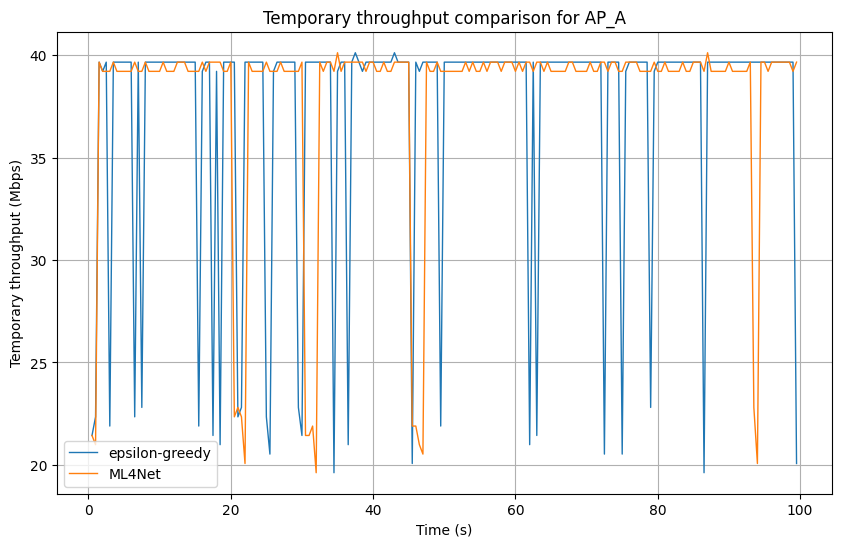

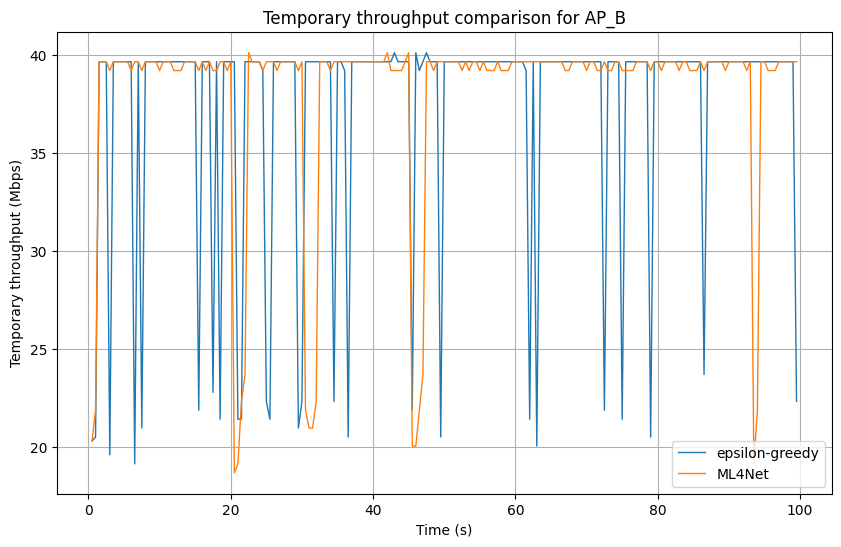

In [ ]:
# Plot temporary throughput comparison

if len(comparison_df) > 0:

    for ap_name in comparison_df["ap"].unique():

        plt.figure(figsize=(10, 6))

        ap_data = comparison_df[comparison_df["ap"] == ap_name]

        for mechanism in ap_data["mechanism"].unique():

            mechanism_data = ap_data[ap_data["mechanism"] == mechanism]

            plt.plot(
                mechanism_data["time"],
                mechanism_data["throughput"],
                linewidth=1,
                label=mechanism
            )

        plt.title(f"Temporary throughput comparison for {ap_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Temporary throughput (Mbps)")
        plt.grid(True)
        plt.legend()
        plt.show()

else:
    print("No throughput data available to plot.")

,mechanism,ap,throughput
0,ML4Net,AP_A,37.977538
1,ML4Net,AP_B,38.071357
2,epsilon-greedy,AP_A,37.363015
3,epsilon-greedy,AP_B,37.364121


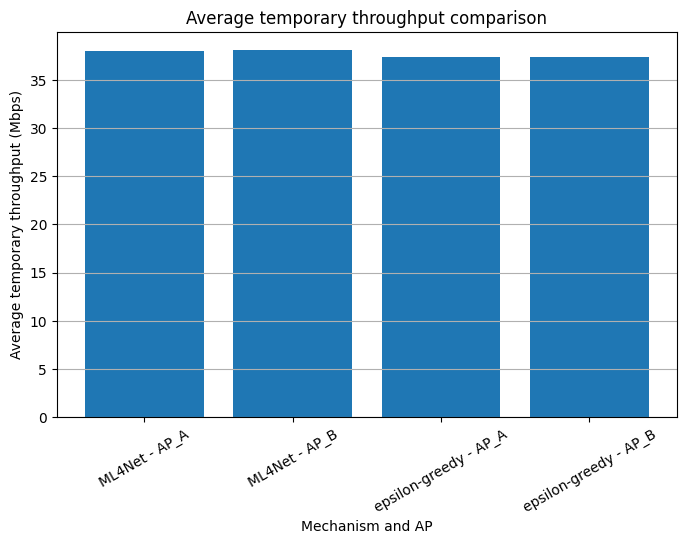

In [ ]:
# Average throughput comparison

average_comparison = (
    comparison_df
    .groupby(["mechanism", "ap"], as_index=False)["throughput"]
    .mean()
)

display(average_comparison)

plt.figure(figsize=(8, 5))

labels = []
values = []

for _, row in average_comparison.iterrows():
    labels.append(row["mechanism"] + " - " + row["ap"])
    values.append(row["throughput"])

plt.bar(labels, values)
plt.title("Average temporary throughput comparison")
plt.xlabel("Mechanism and AP")
plt.ylabel("Average temporary throughput (Mbps)")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

### Comparison between epsilon-greedy and ML4Net

In this part, the custom ML4Net strategy was compared with the epsilon-greedy strategy from the previous simulation. Both approaches use the same Multi-Armed Bandit mechanism and the same action space, where each agent can choose between channel 0 and channel 1.

The temporary throughput values were extracted from the agent log files generated by Komondor. More precisely, the lines containing `Average throughput` were used to build the throughput evolution over time for each AP. The comparison was made for both `AP_A` and `AP_B`.

The plotted curves show that both mechanisms obtain similar throughput values most of the time, usually around 39–40 Mbps. However, both strategies also show occasional drops to around 20–23 Mbps. These drops correspond to moments where the channel selection is less favorable, for example when both BSSs temporarily select the same channel and create more contention.

The average temporary throughput values are also very close. In this simulation, ML4Net obtains approximately 37.98 Mbps for `AP_A` and 38.07 Mbps for `AP_B`, while epsilon-greedy obtains approximately 37.36 Mbps for both APs. Therefore, ML4Net is slightly better in this specific run, but the difference remains small.

The behavior of the two strategies is different. Epsilon-greedy tends to exploit the best-known action more aggressively after some exploration. In the previous logs, one agent mostly selected channel 1 while the other mostly selected channel 0. This means that epsilon-greedy quickly learned a stable channel separation between the two BSSs.

The custom ML4Net strategy is more exploratory because it is inspired by UCB. It gives an exploration bonus to arms that have been selected fewer times. As a result, it keeps testing both channels more regularly instead of converging too quickly to a single preferred action.

Overall, both mechanisms improve the network performance compared with the initial fixed-channel scenario. Epsilon-greedy converges faster toward a stable action, while ML4Net maintains more exploration. In this simulation, ML4Net gives a slightly higher average throughput, but since the comparison is based on one random seed only, more simulations would be needed to draw a stronger conclusion.

### Exercise 6:

Now, modify the "input_nodes.csv" and the input agent files (`agents_egreedy.csv` and `agents_ml4net.csv`) to add a third BSS, which must use the same configuration as the other BSSs but whose AP and STA must be placed at (10,0,0) m and (10,4,0) m, respectively. In the agents file, you will also have to add a third column so that the third BSS gets an agent enrolled.

Run N=5 simulations (using different random seeds) for each action-selection strategy and plot the average throughput obtained by each BSS across the different simulations for each approach.

In [ ]:
# Create input_nodes_3bss.csv with a third valid BSS

input_path = os.path.join(base_path, "input")

input_nodes_path = os.path.join(input_path, "input_nodes.csv")
input_nodes_3bss_path = os.path.join(input_path, "input_nodes_3bss.csv")

nodes_df = pd.read_csv(input_nodes_path, sep=None, engine="python")
nodes_df.columns = [col.strip() for col in nodes_df.columns]

display(nodes_df)
print(nodes_df.columns.tolist())

,node_code,node_type,wlan_code,x(m),y(m),z(m),central_freq (GHz),channel_bonding_model,primary_channel,min_channel_allowed,...,num_packets_aggregated,capture_effect_model,capture_effect_thr,constant PER,pifs_activated,backoff_type,cw_adaptation,cw_min,cw_max,cw_stage
0,AP_A,0,A,0,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
1,STA_A1,1,A,0,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
2,AP_B,0,B,5,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
3,STA_B1,1,B,5,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5


['node_code', 'node_type', 'wlan_code', 'x(m)', 'y(m)', 'z(m)', 'central_freq (GHz)', 'channel_bonding_model', 'primary_channel', 'min_channel_allowed', 'max_channel_allowed', 'tx_power', 'sensitivity', 'traffic_model', 'traffic_load(pkts/s)', 'packet_length', 'num_packets_aggregated', 'capture_effect_model', 'capture_effect_thr', 'constant PER', 'pifs_activated', 'backoff_type', 'cw_adaptation', 'cw_min', 'cw_max', 'cw_stage']


In [ ]:
# Detect useful columns

def find_column_in_df(df, possible_names):
    normalized_columns = {
        col: col.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col in df.columns
    }

    for name in possible_names:
        normalized_name = name.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col, normalized_col in normalized_columns.items():
            if normalized_name in normalized_col:
                return col

    return None


col_node_code = find_column_in_df(nodes_df, ["node code", "node_code", "node", "name"])
col_node_type = find_column_in_df(nodes_df, ["node type", "node_type", "type"])
col_wlan_code = find_column_in_df(nodes_df, ["wlan code", "wlan_code", "wlan"])
col_x = find_column_in_df(nodes_df, ["x"])
col_y = find_column_in_df(nodes_df, ["y"])
col_z = find_column_in_df(nodes_df, ["z"])

print("node code column:", col_node_code)
print("node type column:", col_node_type)
print("wlan code column:", col_wlan_code)
print("x column:", col_x)
print("y column:", col_y)
print("z column:", col_z)

node code column: node_code
node type column: node_type
wlan code column: wlan_code
x column: x(m)
y column: node_type
z column: z(m)


In [ ]:
# Build the third BSS by copying BSS B rows

nodes_3bss = nodes_df.copy()

# Copy AP_B and STA_B1 as templates
ap_template = nodes_df[nodes_df[col_node_code].astype(str).str.contains("AP_B", case=False, na=False)].iloc[0].copy()
sta_template = nodes_df[nodes_df[col_node_code].astype(str).str.contains("STA_B1", case=False, na=False)].iloc[0].copy()

# Create AP_C
ap_c = ap_template.copy()
ap_c[col_node_code] = "AP_C"
ap_c[col_wlan_code] = "C"
ap_c[col_x] = 10
ap_c[col_y] = 0

if col_z is not None:
    ap_c[col_z] = 0

# AP must have node_type = 0
ap_c[col_node_type] = 0

# Create STA_C1
sta_c = sta_template.copy()
sta_c[col_node_code] = "STA_C1"
sta_c[col_wlan_code] = "C"
sta_c[col_x] = 10
sta_c[col_y] = 4

if col_z is not None:
    sta_c[col_z] = 0

# Important correction:
# STA_C1 must have the same type as STA_A1 and STA_B1.
# In the simulator logs, stations have node_type = 1.
sta_c[col_node_type] = 1

# Remove previous C rows if the cell was already run before
nodes_3bss = nodes_3bss[
    ~nodes_3bss[col_node_code].astype(str).str.contains("AP_C|STA_C1", case=False, na=False)
]

# Add the corrected C rows
nodes_3bss = pd.concat(
    [nodes_3bss, pd.DataFrame([ap_c, sta_c])],
    ignore_index=True
)

display(nodes_3bss)

# Save with the same separator style used by Komondor
nodes_3bss.to_csv(input_nodes_3bss_path, sep=";", index=False)

print("input_nodes_3bss.csv created at:")
print(input_nodes_3bss_path)

,node_code,node_type,wlan_code,x(m),y(m),z(m),central_freq (GHz),channel_bonding_model,primary_channel,min_channel_allowed,...,num_packets_aggregated,capture_effect_model,capture_effect_thr,constant PER,pifs_activated,backoff_type,cw_adaptation,cw_min,cw_max,cw_stage
0,AP_A,0,A,0,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
1,STA_A1,1,A,0,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
2,AP_B,0,B,5,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
3,STA_B1,1,B,5,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
4,AP_C,0,C,10,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
5,STA_C1,1,C,10,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5


input_nodes_3bss.csv created at:
/content/drive/MyDrive/AAX/Lab1/input/input_nodes_3bss.csv


In [ ]:
# Create agents_egreedy_3bss.csv and agents_ml4net_3bss.csv

agents_monitoring_path = os.path.join(input_path, "agents_monitoring.csv")

agents_egreedy_3bss_path = os.path.join(input_path, "agents_egreedy_3bss.csv")
agents_ml4net_3bss_path = os.path.join(input_path, "agents_ml4net_3bss.csv")

agents_df = pd.read_csv(agents_monitoring_path, sep=";")
agents_df.columns = [col.strip() for col in agents_df.columns]

display(agents_df)
print(agents_df.columns.tolist())

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,0,-82,15,1,2,0,0
1,B,0,0.5,0,-82,15,1,2,0,0


['Wlan code', 'centralized', 'time between requests (seconds)', 'actions channels', 'actions cca (dBm)', 'actions tx power (dBm)', 'max_bw', 'reward', 'learning mechanism', 'selected_strategy']


In [ ]:
# Detect useful agent columns

def find_agent_column(possible_names):
    normalized_columns = {
        col: col.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col in agents_df.columns
    }

    for name in possible_names:
        normalized_name = name.lower().replace(" ", "").replace("_", "").replace("-", "")
        for col, normalized_col in normalized_columns.items():
            if normalized_name in normalized_col:
                return col

    return None


col_wlan_agent = find_agent_column(["wlan code", "wlan_code", "wlan"])
col_actions_channels = find_agent_column(["actions channels", "action channels", "actions_channels"])
col_learning_mechanism = find_agent_column(["learning mechanism", "learning_mechanism"])
col_selected_strategy = find_agent_column(["selected strategy", "selected_strategy", "strategy"])

print("WLAN column:", col_wlan_agent)
print("actions channels column:", col_actions_channels)
print("learning mechanism column:", col_learning_mechanism)
print("selected strategy column:", col_selected_strategy)

WLAN column: Wlan code
actions channels column: actions channels
learning mechanism column: learning mechanism
selected strategy column: selected_strategy


In [ ]:
# Add a third agent for WLAN C

agents_base_3bss = agents_df.copy()

# Remove previous C agent if the cell was already run before
agents_base_3bss = agents_base_3bss[
    agents_base_3bss[col_wlan_agent].astype(str).str.strip() != "C"
]

# Copy agent B as template
agent_c = agents_df[agents_df[col_wlan_agent].astype(str).str.strip() == "B"].iloc[0].copy()
agent_c[col_wlan_agent] = "C"

agents_base_3bss = pd.concat(
    [agents_base_3bss, pd.DataFrame([agent_c])],
    ignore_index=True
)

# Epsilon-greedy configuration
agents_egreedy_3bss = agents_base_3bss.copy()
agents_egreedy_3bss[col_actions_channels] = "0,1"
agents_egreedy_3bss[col_learning_mechanism] = 1
agents_egreedy_3bss[col_selected_strategy] = 1

# ML4Net configuration
agents_ml4net_3bss = agents_base_3bss.copy()
agents_ml4net_3bss[col_actions_channels] = "0,1"
agents_ml4net_3bss[col_learning_mechanism] = 1
agents_ml4net_3bss[col_selected_strategy] = 5

display(agents_egreedy_3bss)
display(agents_ml4net_3bss)

agents_egreedy_3bss.to_csv(agents_egreedy_3bss_path, sep=";", index=False)
agents_ml4net_3bss.to_csv(agents_ml4net_3bss_path, sep=";", index=False)

print("agents_egreedy_3bss.csv created at:")
print(agents_egreedy_3bss_path)

print("agents_ml4net_3bss.csv created at:")
print(agents_ml4net_3bss_path)

,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,1
1,B,0,0.5,"0,1",-82,15,1,2,1,1
2,C,0,0.5,"0,1",-82,15,1,2,1,1


,Wlan code,centralized,time between requests (seconds),actions channels,actions cca (dBm),actions tx power (dBm),max_bw,reward,learning mechanism,selected_strategy
0,A,0,0.5,"0,1",-82,15,1,2,1,5
1,B,0,0.5,"0,1",-82,15,1,2,1,5
2,C,0,0.5,"0,1",-82,15,1,2,1,5


agents_egreedy_3bss.csv created at:
/content/drive/MyDrive/AAX/Lab1/input/agents_egreedy_3bss.csv
agents_ml4net_3bss.csv created at:
/content/drive/MyDrive/AAX/Lab1/input/agents_ml4net_3bss.csv


In [ ]:
# Quick verification before running simulations

check_nodes = pd.read_csv(input_nodes_3bss_path, sep=";")

display(check_nodes)

print("Rows for BSS C:")
display(check_nodes[check_nodes[col_wlan_code].astype(str).str.strip() == "C"])

,node_code,node_type,wlan_code,x(m),y(m),z(m),central_freq (GHz),channel_bonding_model,primary_channel,min_channel_allowed,...,num_packets_aggregated,capture_effect_model,capture_effect_thr,constant PER,pifs_activated,backoff_type,cw_adaptation,cw_min,cw_max,cw_stage
0,AP_A,0,A,0,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
1,STA_A1,1,A,0,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
2,AP_B,0,B,5,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
3,STA_B1,1,B,5,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
4,AP_C,0,C,10,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
5,STA_C1,1,C,10,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5


Rows for BSS C:


,node_code,node_type,wlan_code,x(m),y(m),z(m),central_freq (GHz),channel_bonding_model,primary_channel,min_channel_allowed,...,num_packets_aggregated,capture_effect_model,capture_effect_thr,constant PER,pifs_activated,backoff_type,cw_adaptation,cw_min,cw_max,cw_stage
4,AP_C,0,C,10,0,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5
5,STA_C1,1,C,10,4,0,5,4,0,0,...,64,0,10,0,0,0,0,0,15,5


In [ ]:
# Run N = 5 simulations for epsilon-greedy and ML4Net

# Clean previous EX6 output files to avoid parsing old failed simulations
old_files = glob.glob(os.path.join(output_path, "*AAX-LAB1-EX6*"))

for file in old_files:
    os.remove(file)

seeds = [7, 13, 21, 42, 100]

simulation_configs = [
    {
        "mechanism": "epsilon-greedy",
        "agents_file": "../input/agents_egreedy_3bss.csv",
        "code_prefix": "AAX-LAB1-EX6-EGREEDY"
    },
    {
        "mechanism": "ML4Net",
        "agents_file": "../input/agents_ml4net_3bss.csv",
        "code_prefix": "AAX-LAB1-EX6-ML4NET"
    }
]

INPUT_FILE_NODES = "../input/input_nodes_3bss.csv"

FLAG_SAVE_NODE_LOGS = 0
FLAG_SAVE_AGENT_LOGS = 1

FLAG_PRINT_SYSTEM_LOGS = 1
FLAG_PRINT_NODE_LOGS = 1
FLAG_PRINT_AGENT_LOGS = 0

SIM_TIME = 100

for config in simulation_configs:

    print("\n==============================")
    print("Running mechanism:", config["mechanism"])
    print("==============================")

    for seed in seeds:

        print("\nRunning seed:", seed)

        INPUT_FILE_AGENTS = config["agents_file"]
        SIMULATION_CODE = config["code_prefix"] + "-SEED-" + str(seed)
        OUTPUT_FILE_LOGS = "../output/logs_" + SIMULATION_CODE + ".txt"
        SEED = seed

        !cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


Running mechanism: epsilon-greedy

Running seed: 7

*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_3bss.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_egreedy_3bss.csv
  - script_output_filename: ../output/logs_AAX-LAB1-EX6-EGREEDY-SEED-7.txt
  - simulation_code: AAX-LAB1-EX6-EGREEDY-SEED-7
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EX6-EGREEDY-SEED-7.txt' created!

 Reading system confi

In [ ]:
# Robust extraction for Exercise 6

import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

seeds = [7, 13, 21, 42, 100]

simulation_configs = [
    {
        "mechanism": "epsilon-greedy",
        "code_prefix": "AAX-LAB1-EX6-EGREEDY"
    },
    {
        "mechanism": "ML4Net",
        "code_prefix": "AAX-LAB1-EX6-ML4NET"
    }
]

# Search pattern for AP throughput blocks
throughput_pattern = re.compile(
    r"-------\s+(AP_[A-Z])\s+\(N\d+\)\s+------.*?"
    r"Throughput\s+=\s+([0-9]+(?:\.[0-9]+)?)\s+Mbps",
    re.DOTALL
)

results = []

print("Output path used:", output_path)
print()

for config in simulation_configs:
    mechanism = config["mechanism"]
    code_prefix = config["code_prefix"]

    for seed in seeds:
        sim_code = f"{code_prefix}-SEED-{seed}"

        # Look for every file containing the simulation code
        candidate_files = glob.glob(os.path.join(output_path, f"*{sim_code}*.txt"))

        print(f"\nSimulation: {sim_code}")
        print("Candidate files:")
        for file in candidate_files:
            print(" -", file)

        found_for_this_sim = False

        for log_file in candidate_files:
            with open(log_file, "r", encoding="utf-8", errors="ignore") as f:
                content = f.read()

            matches = throughput_pattern.findall(content)

            if len(matches) > 0:
                print(f"  -> Throughput found in: {os.path.basename(log_file)}")

                for ap_name, throughput in matches:
                    results.append({
                        "mechanism": mechanism,
                        "seed": seed,
                        "bss": ap_name.replace("AP_", "BSS "),
                        "throughput_mbps": float(throughput),
                        "file": os.path.basename(log_file)
                    })

                found_for_this_sim = True
                break

        if not found_for_this_sim:
            print("  -> No throughput found in these files.")

results_df = pd.DataFrame(results)

print("\nExtracted results:")
display(results_df)

if results_df.empty:
    print("No throughput values were extracted.")
    print("This means the files in output_path do not contain the AP_A/AP_B/AP_C throughput blocks.")
    print("The values you see are probably only printed in the notebook output, not saved in the log files.")
else:
    print("Number of extracted values per mechanism and BSS:")
    display(
        results_df
        .groupby(["mechanism", "bss"])
        .size()
        .reset_index(name="count")
    )

Output path used: /content/drive/MyDrive/AAX/Lab1/output


Simulation: AAX-LAB1-EX6-EGREEDY-SEED-7
Candidate files:
 - /content/drive/MyDrive/AAX/Lab1/output/logs_AAX-LAB1-EX6-EGREEDY-SEED-7.txt
 - /content/drive/MyDrive/AAX/Lab1/output/logs_output_AAX-LAB1-EX6-EGREEDY-SEED-7_A0_A.txt
 - /content/drive/MyDrive/AAX/Lab1/output/logs_output_AAX-LAB1-EX6-EGREEDY-SEED-7_A1_B.txt
 - /content/drive/MyDrive/AAX/Lab1/output/logs_output_AAX-LAB1-EX6-EGREEDY-SEED-7_A2_C.txt
  -> No throughput found in these files.

Simulation: AAX-LAB1-EX6-EGREEDY-SEED-13
Candidate files:
 - /content/drive/MyDrive/AAX/Lab1/output/logs_AAX-LAB1-EX6-EGREEDY-SEED-13.txt
 - /content/drive/MyDrive/AAX/Lab1/output/logs_output_AAX-LAB1-EX6-EGREEDY-SEED-13_A0_A.txt
 - /content/drive/MyDrive/AAX/Lab1/output/logs_output_AAX-LAB1-EX6-EGREEDY-SEED-13_A1_B.txt
 - /content/drive/MyDrive/AAX/Lab1/output/logs_output_AAX-LAB1-EX6-EGREEDY-SEED-13_A2_C.txt
  -> No throughput found in these files.

Simulation: AAX-LAB1-EX6-EGREEDY-S

""


No throughput values were extracted.
This means the files in output_path do not contain the AP_A/AP_B/AP_C throughput blocks.
The values you see are probably only printed in the notebook output, not saved in the log files.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = [
    # epsilon-greedy
    {"mechanism": "epsilon-greedy", "seed": 7,   "bss": "BSS A", "throughput_mbps": 38.258400},
    {"mechanism": "epsilon-greedy", "seed": 7,   "bss": "BSS B", "throughput_mbps": 34.241040},
    {"mechanism": "epsilon-greedy", "seed": 7,   "bss": "BSS C", "throughput_mbps": 38.174040},

    {"mechanism": "epsilon-greedy", "seed": 13,  "bss": "BSS A", "throughput_mbps": 38.078280},
    {"mechanism": "epsilon-greedy", "seed": 13,  "bss": "BSS B", "throughput_mbps": 35.289840},
    {"mechanism": "epsilon-greedy", "seed": 13,  "bss": "BSS C", "throughput_mbps": 38.361000},

    {"mechanism": "epsilon-greedy", "seed": 21,  "bss": "BSS A", "throughput_mbps": 38.119320},
    {"mechanism": "epsilon-greedy", "seed": 21,  "bss": "BSS B", "throughput_mbps": 35.296680},
    {"mechanism": "epsilon-greedy", "seed": 21,  "bss": "BSS C", "throughput_mbps": 38.525160},

    {"mechanism": "epsilon-greedy", "seed": 42,  "bss": "BSS A", "throughput_mbps": 38.484120},
    {"mechanism": "epsilon-greedy", "seed": 42,  "bss": "BSS B", "throughput_mbps": 34.904520},
    {"mechanism": "epsilon-greedy", "seed": 42,  "bss": "BSS C", "throughput_mbps": 38.290320},

    {"mechanism": "epsilon-greedy", "seed": 100, "bss": "BSS A", "throughput_mbps": 38.260680},
    {"mechanism": "epsilon-greedy", "seed": 100, "bss": "BSS B", "throughput_mbps": 34.763160},
    {"mechanism": "epsilon-greedy", "seed": 100, "bss": "BSS C", "throughput_mbps": 38.112480},

    # ML4Net
    {"mechanism": "ML4Net", "seed": 7,   "bss": "BSS A", "throughput_mbps": 37.006680},
    {"mechanism": "ML4Net", "seed": 7,   "bss": "BSS B", "throughput_mbps": 33.543360},
    {"mechanism": "ML4Net", "seed": 7,   "bss": "BSS C", "throughput_mbps": 38.069160},

    {"mechanism": "ML4Net", "seed": 13,  "bss": "BSS A", "throughput_mbps": 38.411160},
    {"mechanism": "ML4Net", "seed": 13,  "bss": "BSS B", "throughput_mbps": 36.313560},
    {"mechanism": "ML4Net", "seed": 13,  "bss": "BSS C", "throughput_mbps": 37.563000},

    {"mechanism": "ML4Net", "seed": 21,  "bss": "BSS A", "throughput_mbps": 38.826120},
    {"mechanism": "ML4Net", "seed": 21,  "bss": "BSS B", "throughput_mbps": 36.614520},
    {"mechanism": "ML4Net", "seed": 21,  "bss": "BSS C", "throughput_mbps": 37.836600},

    {"mechanism": "ML4Net", "seed": 42,  "bss": "BSS A", "throughput_mbps": 35.982960},
    {"mechanism": "ML4Net", "seed": 42,  "bss": "BSS B", "throughput_mbps": 29.874840},
    {"mechanism": "ML4Net", "seed": 42,  "bss": "BSS C", "throughput_mbps": 35.978400},

    {"mechanism": "ML4Net", "seed": 100, "bss": "BSS A", "throughput_mbps": 36.005760},
    {"mechanism": "ML4Net", "seed": 100, "bss": "BSS B", "throughput_mbps": 30.116520},
    {"mechanism": "ML4Net", "seed": 100, "bss": "BSS C", "throughput_mbps": 36.484560},
]

results_df = pd.DataFrame(results)

display(results_df)

,mechanism,seed,bss,throughput_mbps
0,epsilon-greedy,7,BSS A,38.25840
1,epsilon-greedy,7,BSS B,34.24104
2,epsilon-greedy,7,BSS C,38.17404
3,epsilon-greedy,13,BSS A,38.07828
4,epsilon-greedy,13,BSS B,35.28984
5,epsilon-greedy,13,BSS C,38.36100
6,epsilon-greedy,21,BSS A,38.11932
7,epsilon-greedy,21,BSS B,35.29668
8,epsilon-greedy,21,BSS C,38.52516
9,epsilon-greedy,42,BSS A,38.48412


In [ ]:
average_results = (
    results_df
    .groupby(["mechanism", "bss"], as_index=False)["throughput_mbps"]
    .mean()
)

display(average_results)

,mechanism,bss,throughput_mbps
0,ML4Net,BSS A,37.246536
1,ML4Net,BSS B,33.292560
2,ML4Net,BSS C,37.186344
3,epsilon-greedy,BSS A,38.240160
4,epsilon-greedy,BSS B,34.899048
5,epsilon-greedy,BSS C,38.292600


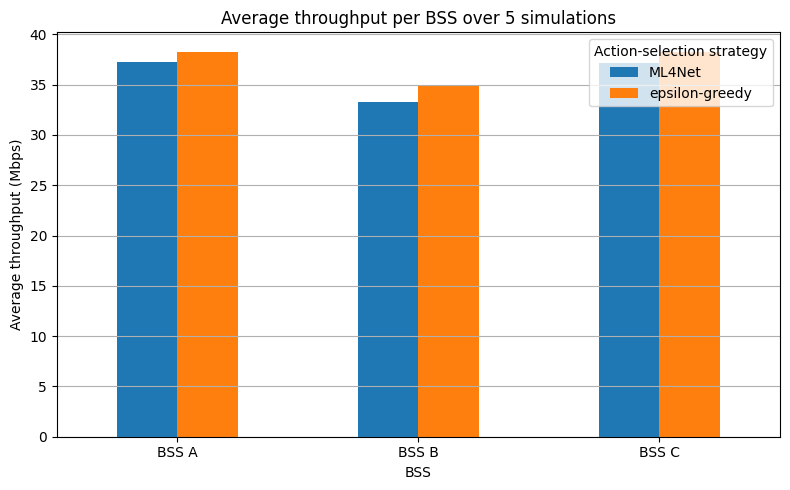

In [ ]:
plot_df = average_results.pivot(
    index="bss",
    columns="mechanism",
    values="throughput_mbps"
)

ax = plot_df.plot(kind="bar", figsize=(8, 5))

plt.title("Average throughput per BSS over 5 simulations")
plt.xlabel("BSS")
plt.ylabel("Average throughput (Mbps)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Action-selection strategy")
plt.tight_layout()
plt.show()

In this exercise, the third BSS was added with the same configuration as the previous BSSs.
The AP and STA of BSS C were placed at (10, 0, 0) m and (10, 4, 0) m.
Five simulations were run for each action-selection strategy using different random seeds.

The results show that epsilon-greedy gives slightly higher and more stable average throughput than ML4Net in this configuration.
BSS A and BSS C obtain similar throughput because they are placed at the edges of the topology, while BSS B obtains lower throughput because it is located between the two other BSSs and is therefore more affected by interference.